In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [11]:
def kernel(f, sigma=6.5):
    sigma0 = 4
    sigmat = np.sqrt(sigma**2 - sigma0**2)
    fsize = f.shape[0]
    ticks = np.linspace(0, fsize-1, fsize)
    ticks[ticks > fsize//2] = ticks[ticks > fsize//2] - fsize
    kernel = np.exp(-(ticks)**2 / (2*sigmat**2))
    return kernel / kernel.sum()

def convolve(f1, f2):
    '''
    Return the simple convolution of the two arrays using FFT+mult+invFFT method.
    '''
    # fftconvolve adds an unwanted time shift
    #from scipy.signal import fftconvolve
    #return fftconvolve(field, elect, "same")
    s1 = np.fft.fft(f1)
    s2 = np.fft.fft(f2)
    sig = np.fft.ifft(s1*s2)

    return np.real(sig)

def smear(f, smearing=7.5):
    # f = f.T

    k = kernel(f, smearing)
    
    out = np.zeros(f.shape)
    for i in range(f.shape[1]):
        out[:, i] = convolve(f[:, i], k)
    
    # out = out.T
    # case to float
    out = out.astype(np.float32)

    return out

(512, 512)


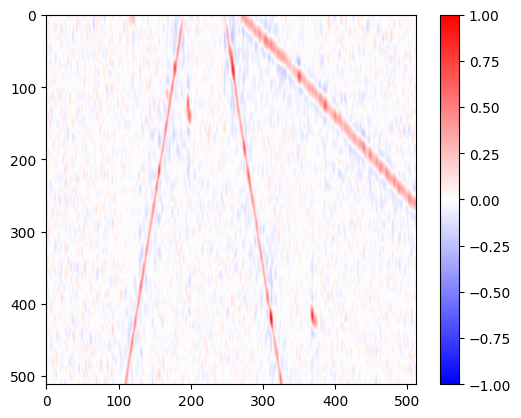

In [3]:
filename = "/scratch/7DayLifetime/gputnam/raw-sq-wtruth/tpc2_plane0_rec_67583145_10.npz"
frames = np.load(filename)

fidx = 3
this_frame = frames["reco"][fidx][0]
print(this_frame.shape)

plt.imshow(this_frame, vmin = -1, vmax=1, cmap="bwr")
plt.colorbar()
plt.show();

In [4]:
from math import e


def make_diseased_samples(this_frame,mode="erase", plot=False):
    aug_frame = this_frame.copy()

    if mode == "erase":
        # Erase a random band of wires
        band_width = np.random.randint(5, 31)  # Random width between 5 and 30 inclusive
        num_wires = this_frame.shape[1]
        if num_wires > band_width:
            erase_start = np.random.randint(0, num_wires - band_width + 1)
            erase_end = erase_start + band_width
        else:
            erase_start = 0
            erase_end = num_wires
        aug_frame[:, erase_start:erase_end] = 0

    elif mode == "smear":
        smearing = np.random.uniform(4.5, 6.5)
        aug_frame = smear(aug_frame, smearing=smearing)

    elif mode == "random_weight":
        scale = np.random.uniform(0.05, 0.15)
        weights = np.random.normal(1, scale, this_frame.shape)
        aug_frame = aug_frame * weights

    elif mode == "uniform_weight":
        scale = np.random.uniform(0.85, 1.15)
        weights = np.ones(this_frame.shape)*scale
        aug_frame = aug_frame * weights

    else:
        raise ValueError(f"Invalid mode: {mode}")

    if plot:
        fig, ax = plt.subplots()
        plt.imshow(aug_frame, aspect="auto", cmap="bwr", origin="lower", vmin=-1*1, vmax=1)
        plt.xlabel("Wire")
        plt.ylabel("Tick")
        plt.colorbar()
        plt.show();

    return aug_frame

In [5]:
from os import listdir

in_filedir = "/scratch/7DayLifetime/gputnam/raw-sq-wtruth"
filelist = listdir(in_filedir)
filelist = [f[:-4] for f in filelist if f.endswith(".npz") and "plane0" in f]
print(len(filelist))

1726


In [ ]:
disease_mode = "smear"

in_filedir = "/scratch/7DayLifetime/gputnam/raw-sq-wtruth"
# in_filename = "tpc2_plane0_rec_67583145_10"
for in_filename in tqdm(filelist[:100]):
    in_file = in_filedir + "/" + in_filename + ".npz"

    out_filedir = f"/scratch/7DayLifetime/munjung/anomaly-detection/diseased/{disease_mode}"
    out_filename = in_filename + f"_diseased_{disease_mode}.npz"
    out_file = out_filedir + "/" + out_filename

    samples = np.load(in_file)
    print(samples["reco"].shape)
    frames = []
    frames_truth = []
    for i in range(samples["reco"].shape[0]):
        this_frame = samples["reco"][i][0]
        this_frame_truth = samples["truth"][i][0]
        this_frame_diseased = make_diseased_samples(this_frame, mode=disease_mode, plot=False)
        frames.append(this_frame_diseased[None, ...])
        frames_truth.append(this_frame_truth[None, ...])
    stacked = np.stack(frames, axis=0)  # shape (n,1,512,512)
    stacked_truth = np.stack(frames_truth, axis=0)  # shape (n,1,512,512)

    np.savez_compressed(
        out_file,
        reco=stacked.astype(np.float32),
        truth=stacked_truth.astype(np.float32)
    )
    print(f"Saved {out_file}: reco {stacked.shape}, truth {stacked.shape}")

  0%|          | 0/100 [00:00<?, ?it/s]

(160, 1, 512, 512)


  1%|          | 1/100 [00:32<53:46, 32.59s/it]

Saved /scratch/7DayLifetime/munjung/anomaly-detection/diseased/smear/tpc1_plane0_rec_67583145_33_diseased_smear.npz: reco (160, 1, 512, 512), truth (160, 1, 512, 512)
(160, 1, 512, 512)


  2%|▏         | 2/100 [01:04<52:37, 32.22s/it]

Saved /scratch/7DayLifetime/munjung/anomaly-detection/diseased/smear/tpc3_plane0_rec_82090893_295_diseased_smear.npz: reco (160, 1, 512, 512), truth (160, 1, 512, 512)
(160, 1, 512, 512)


  3%|▎         | 3/100 [01:36<52:09, 32.27s/it]

Saved /scratch/7DayLifetime/munjung/anomaly-detection/diseased/smear/tpc1_plane0_rec_82090893_283_diseased_smear.npz: reco (160, 1, 512, 512), truth (160, 1, 512, 512)
(160, 1, 512, 512)
